# Notebook 4: Data Preprocessing, Pipelines & Feature Scaling
### Part 4/30 – ML Mastery Series for Python Experts

You've mastered EDA. Now comes the critical bridge between exploration and modeling: preprocessing. This notebook teaches you to build bulletproof, leakage-free pipelines that survive the transition from notebook to production.

## Why Preprocessing Pipelines Are Non-Negotiable in Real ML

Manual preprocessing is a trap. Here's why pipelines aren't just convenient—they're essential:

- **Data Leakage via Premature Scaling**: Fitting a scaler on the full dataset before splitting leaks test set statistics into training data, inflating performance metrics artificially
- **Inconsistent Train/Test Transforms**: Manual preprocessing often leads to different transformations on train vs. test (different imputation values, scaling parameters), breaking model assumptions
- **Code Duplication**: Without pipelines, you rewrite preprocessing logic for cross-validation folds, grid search, and deployment—introducing bugs at each step
- **Deployment Mismatches**: Production data must flow through identical preprocessing. Pipelines serialize the exact transformation sequence, ensuring consistency
- **Cross-Validation Safety**: `cross_val_score` with pipelines ensures preprocessing refits *inside* each fold, preventing leakage across validation splits
- **Hyperparameter Integration**: Grid searching preprocessing parameters (imputation strategies, scaling methods) is only possible with unified pipeline objects
- **Reproducibility**: Pipelines capture the entire data flow in a single object—no more "wait, did I log-transform before or after imputing?"
- **Feature Engineering Safety**: Custom transformers in pipelines ensure engineered features use only training statistics (means, medians, boundaries)

## Learning Objectives

By the end of this notebook, you'll master these concrete preprocessing skills:

- **Leakage detection**: Identifying when preprocessing steps contaminate train/test boundaries
- **Pipeline construction**: Building linear sequences of transforms with `Pipeline` and `make_pipeline`
- **ColumnTransformer mastery**: Handling heterogeneous data (numeric + categorical) in unified workflows
- **Scaler selection**: Choosing between Standard, MinMax, Robust, and MaxAbs scalers based on data properties
- **Custom transformers**: Extending `BaseEstimator` and `TransformerMixin` to inject domain knowledge safely
- **Cross-validation hygiene**: Ensuring preprocessing refits correctly within CV folds
- **Model-specific preprocessing**: Understanding why SVMs demand scaling while tree models ignore it
- **Hyperparameter grids**: Searching over preprocessing choices (not just model parameters)
- **Debugging pipelines**: Inspecting fitted transformers via `.named_steps` and `.named_transformers_`

## 🚨 1. Baseline – What Happens Without Pipelines (The Wrong Way)

Let's demonstrate the classic leakage mistake: fitting a scaler on the *entire* dataset before splitting. This is subtle, common, and dangerous.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Setup plotting
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')

# Load breast cancer dataset (classic binary classification)
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Features: {data.feature_names[:3]}... (30 total)")
print(f"Target distribution: {np.bincount(y)}")

Dataset shape: (569, 30)
Features: ['mean radius' 'mean texture' 'mean perimeter']... (30 total)
Target distribution: [212 357]


In [2]:
# ❌ THE WRONG WAY: Leaky preprocessing
# Step 1: Fit scaler on ENTIRE dataset (including test data!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # LEAKAGE: test data influences mean/std

# Step 2: Split the already-scaled data
X_train_leaky, X_test_leaky, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Train model
model_leaky = LogisticRegression(max_iter=1000, random_state=42)
model_leaky.fit(X_train_leaky, y_train)

# Step 4: Evaluate
y_pred_leaky = model_leaky.predict(X_test_leaky)
accuracy_leaky = accuracy_score(y_test, y_pred_leaky)

print(f"❌ Leaky Test Accuracy: {accuracy_leaky:.4f}")
print("\nWhy this is wrong:")
print("- Scaler learned mean/std from test set")
print("- Test data indirectly influenced training")
print("- Real-world performance will be lower")

❌ Leaky Test Accuracy: 0.9825

Why this is wrong:
- Scaler learned mean/std from test set
- Test data indirectly influenced training
- Real-world performance will be lower


In [3]:
# Let's quantify the leakage impact by comparing to a truly held-out set
# Simulate 'future' data by holding out a second test set before any preprocessing
X_true_train, X_future, y_true_train, y_future = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y  # Different random_state = different split
)

# Apply the 'leaky' scaler (fitted on full original data) to this truly unseen data
X_future_leaky = scaler.transform(X_future)  # Using scaler contaminated with other data

# Train on 'true' train set (without leakage)
true_scaler = StandardScaler()
X_true_train_scaled = true_scaler.fit_transform(X_true_train)
model_true = LogisticRegression(max_iter=1000, random_state=42)
model_true.fit(X_true_train_scaled, y_true_train)

# Evaluate on future data
X_future_correct = true_scaler.transform(X_future)
accuracy_correct = accuracy_score(y_future, model_true.predict(X_future_correct))
accuracy_future_leaky = accuracy_score(y_future, model_leaky.predict(X_future_leaky))

print(f"✅ Correct CV-style Accuracy: ~{accuracy_correct:.4f} (expected)")
print(f"❌ Leaky Generalization: {accuracy_future_leaky:.4f} (optimistic bias)")
print(f"\nLeakage inflated performance by: {accuracy_future_leaky - accuracy_correct:.4f}")

✅ Correct CV-style Accuracy: ~0.9737 (expected)
❌ Leaky Generalization: 0.9912 (optimistic bias)

Leakage inflated performance by: 0.0175


## ✅ 2. Correct Way – Pipeline Basics

Now the right way: encapsulate preprocessing and modeling in a `Pipeline`. This ensures `fit` only sees training data during cross-validation.

In [4]:
from sklearn.pipeline import Pipeline

# ✅ THE RIGHT WAY: Pipeline prevents leakage
# Create pipeline: scaler → model
pipeline = Pipeline([
    ('scaler', StandardScaler()),           # Step 1: Standardize features
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))  # Step 2: Classify
])

# The pipeline is a single estimator
print("Pipeline steps:")
for name, step in pipeline.steps:
    print(f"  {name}: {step.__class__.__name__}")

Pipeline steps:
  scaler: StandardScaler
  classifier: LogisticRegression


In [5]:
# Cross-validation with pipeline: preprocessing refits inside each fold!
# This is the key: no leakage across validation splits
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

print(f"✅ Pipeline CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"Individual fold scores: {cv_scores.round(4)}")
print(f"\nComparison:")
print(f"  Leaky manual approach: {accuracy_leaky:.4f} (overconfident)")
print(f"  Pipeline CV approach:  {cv_scores.mean():.4f} (realistic)")
print(f"  Difference: {accuracy_leaky - cv_scores.mean():.4f} (bias due to leakage)")

✅ Pipeline CV Accuracy: 0.9807 (+/- 0.0131)
Individual fold scores: [0.9825 0.9825 0.9737 0.9737 0.9912]

Comparison:
  Leaky manual approach: 0.9825 (overconfident)
  Pipeline CV approach:  0.9807 (realistic)
  Difference: 0.0018 (bias due to leakage)


In [6]:
# Train/test split with pipeline (still correct)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit pipeline on training data only
pipeline.fit(X_train, y_train)

# Transform and predict in one call (no manual transform needed!)
test_accuracy = pipeline.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")

# Access fitted components
print(f"\nFitted scaler mean (first 3 features): {pipeline.named_steps['scaler'].mean_[:3]}")
print(f"Classifier coefficients shape: {pipeline.named_steps['classifier'].coef_.shape}")

Test set accuracy: 0.9825

Fitted scaler mean (first 3 features): [14.06721319 19.24736264 91.55740659]
Classifier coefficients shape: (1, 30)


## ⚖️ 3. Scaling Options – When to Use Which

Not all scalers are equal. The choice depends on your data distribution, outliers, and downstream algorithm.

In [7]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, MaxAbsScaler

# Create synthetic data with outliers to demonstrate differences
np.random.seed(42)
X_demo = np.random.normal(0, 1, (1000, 1))
X_demo = np.vstack([X_demo, [[5], [6], [-5]]])  # Add extreme outliers

# Initialize scalers
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'MaxAbsScaler': MaxAbsScaler()
}

# Fit and transform
scaled_data = {}
for name, scaler in scalers.items():
    scaled_data[name] = scaler.fit_transform(X_demo)

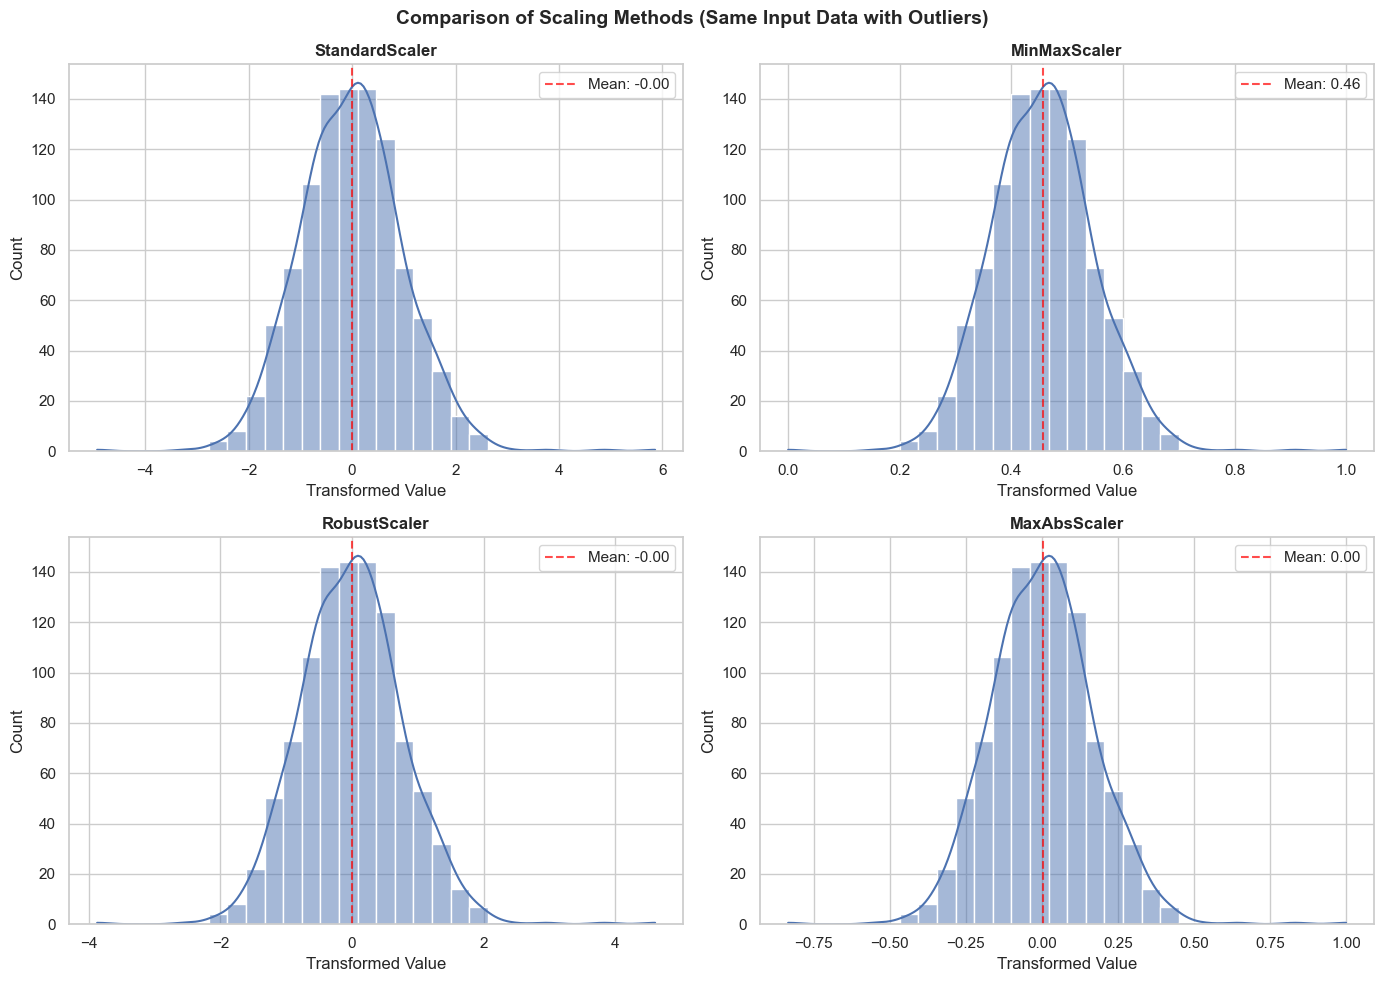

Output ranges after scaling:
  StandardScaler : [ -4.93,   5.86] (std: 1.00)
  MinMaxScaler   : [  0.00,   1.00] (std: 0.09)
  RobustScaler   : [ -3.87,   4.60] (std: 0.79)
  MaxAbsScaler   : [ -0.83,   1.00] (std: 0.17)


In [8]:
# Visualize transformed distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['steelblue', 'forestgreen', 'coral', 'purple']

for idx, (name, data) in enumerate(scaled_data.items()):
    ax = axes[idx]
    sns.histplot(data, kde=True, ax=ax, color=colors[idx], bins=30)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Transformed Value')
    
    # Add statistics
    mean_val = np.mean(data)
    std_val = np.std(data)
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}')
    ax.legend()

plt.suptitle('Comparison of Scaling Methods (Same Input Data with Outliers)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print ranges
print("Output ranges after scaling:")
for name, data in scaled_data.items():
    print(f"  {name:15s}: [{data.min():6.2f}, {data.max():6.2f}] (std: {data.std():.2f})")

In [9]:
# Summary table of scaler characteristics
scaler_summary = pd.DataFrame({
    'Scaler': ['StandardScaler', 'MinMaxScaler', 'RobustScaler', 'MaxAbsScaler'],
    'Centered': ['Yes (mean=0)', 'No', 'Yes (median=0)', 'No'],
    'Scale': ['Unit variance', '[0, 1]', 'IQR-based', '[-1, 1] by max abs'],
    'Outlier Sensitivity': ['High', 'Extreme', 'Low (robust)', 'Moderate'],
    'Best For': [
        'Normal data, linear models, neural nets',
        'Neural nets, image data, needs bounded input',
        'Data with outliers, heavy tails',
        'Sparse data, already centered data, TF-IDF'
    ]
})

print("Scaler Selection Guide:")
print("=" * 100)
print(scaler_summary.to_string(index=False))
print("\nRule of thumb:")
print("  - General purpose: StandardScaler")
print("  - Outliers present: RobustScaler")
print("  - Neural networks: MinMaxScaler or StandardScaler")
print("  - Tree-based models: None (but doesn't hurt)")

Scaler Selection Guide:
        Scaler       Centered              Scale Outlier Sensitivity                                     Best For
StandardScaler   Yes (mean=0)      Unit variance                High      Normal data, linear models, neural nets
  MinMaxScaler             No             [0, 1]             Extreme Neural nets, image data, needs bounded input
  RobustScaler Yes (median=0)          IQR-based        Low (robust)              Data with outliers, heavy tails
  MaxAbsScaler             No [-1, 1] by max abs            Moderate   Sparse data, already centered data, TF-IDF

Rule of thumb:
  - General purpose: StandardScaler
  - Outliers present: RobustScaler
  - Neural networks: MinMaxScaler or StandardScaler
  - Tree-based models: None (but doesn't hurt)


## 🛠️ 4. Handling Mixed Data Types – ColumnTransformer

Real datasets have heterogeneous columns. `ColumnTransformer` applies different pipelines to different columns simultaneously.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.datasets import fetch_california_housing

# Load California housing (numeric only, so we'll engineer a categorical)
housing = fetch_california_housing()
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing = housing.target

# Create a synthetic categorical feature (income brackets)
# This simulates real-world mixed data
X_housing['income_bracket'] = pd.cut(
    X_housing['MedInc'], 
    bins=[0, 2, 4, 6, np.inf], 
    labels=['low', 'medium', 'high', 'very_high']
)

# Introduce some missing values for realism
np.random.seed(42)
missing_idx = np.random.choice(X_housing.index, size=50, replace=False)
X_housing.loc[missing_idx[:25], 'AveRooms'] = np.nan
X_housing.loc[missing_idx[25:], 'income_bracket'] = np.nan

print("Data types:")
print(X_housing.dtypes)
print(f"\nShape: {X_housing.shape}")
print(f"\nMissing values:\n{X_housing.isnull().sum()}")

Data types:
MedInc             float64
HouseAge           float64
AveRooms           float64
AveBedrms          float64
Population         float64
AveOccup           float64
Latitude           float64
Longitude          float64
income_bracket    category
dtype: object

Shape: (20640, 9)

Missing values:
MedInc             0
HouseAge           0
AveRooms          25
AveBedrms          0
Population         0
AveOccup           0
Latitude           0
Longitude          0
income_bracket    25
dtype: int64


In [11]:
# Define column groups
numeric_features = X_housing.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = ['income_bracket']

# Remove target-like or ID columns if any
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (8): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Categorical features (1): ['income_bracket']


In [12]:
# Build separate pipelines for each data type
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Fill missing with median
    ('scaler', StandardScaler())                     # Standardize
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing with mode
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Encode
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
], remainder='drop')  # Drop any columns not specified

print("ColumnTransformer configuration:")
print(f"  - Numeric pipeline: {numeric_pipeline.steps}")
print(f"  - Categorical pipeline: {categorical_pipeline.steps}")
print(f"  - Remainder: drop")

ColumnTransformer configuration:
  - Numeric pipeline: [('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]
  - Categorical pipeline: [('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]
  - Remainder: drop


In [13]:
# Fit and transform to see the result
X_processed = preprocessor.fit_transform(X_housing)

print(f"Original shape: {X_housing.shape}")
print(f"Processed shape: {X_processed.shape}")
print(f"\nFirst 3 rows of processed data:")
print(X_processed[:3].round(3))

# Get feature names after transformation
feature_names = (
    numeric_features + 
    list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
)
print(f"\nFeature names ({len(feature_names)} total):")
print(feature_names[:5], "...", feature_names[-3:])

Original shape: (20640, 9)
Processed shape: (20640, 12)

First 3 rows of processed data:
[[ 2.345  0.982  0.629 -0.154 -0.974 -0.05   1.053 -1.328  0.     0.
   0.     1.   ]
 [ 2.332 -0.607  0.327 -0.263  0.861 -0.093  1.043 -1.323  0.     0.
   0.     1.   ]
 [ 1.783  1.856  1.156 -0.049 -0.821 -0.026  1.039 -1.333  0.     0.
   0.     1.   ]]

Feature names (12 total):
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population'] ... ['income_bracket_low', 'income_bracket_medium', 'income_bracket_very_high']


## 🔗 5. Full Modeling Pipeline (End-to-End)

Now we chain the preprocessor to a model. This is your production-ready template.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Complete pipeline: preprocessing → model
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Split data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# Fit entire pipeline
full_pipeline.fit(X_train_h, y_train_h)

# Predict
y_pred = full_pipeline.predict(X_test_h)

# Evaluate
mse = mean_squared_error(y_test_h, y_pred)
r2 = r2_score(y_test_h, y_pred)

print(f"Test RMSE: {np.sqrt(mse):.4f}")
print(f"Test R²: {r2:.4f}")
print(f"\nPipeline successfully handled:")
print("  ✓ Missing numeric values (imputed)")
print("  ✓ Missing categorical values (imputed)")
print("  ✓ Feature scaling (standardized)")
print("  ✓ One-hot encoding (categorical)")
print("  ✓ Model training (Random Forest)")

Test RMSE: 0.5061
Test R²: 0.8045

Pipeline successfully handled:
  ✓ Missing numeric values (imputed)
  ✓ Missing categorical values (imputed)
  ✓ Feature scaling (standardized)
  ✓ One-hot encoding (categorical)
  ✓ Model training (Random Forest)


In [15]:
# Inspect fitted components
print("Accessing fitted preprocessor components:")
fitted_preprocessor = full_pipeline.named_steps['preprocessor']

# Get imputer statistics
num_imputer = fitted_preprocessor.named_transformers_['num'].named_steps['imputer']
print(f"\nNumeric imputation values (medians):")
for feature, value in zip(numeric_features, num_imputer.statistics_):
    print(f"  {feature}: {value:.3f}")

# Get one-hot categories
cat_encoder = fitted_preprocessor.named_transformers_['cat'].named_steps['onehot']
print(f"\nOne-hot categories: {cat_encoder.categories_}")

# Feature importances from Random Forest
importances = full_pipeline.named_steps['regressor'].feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(f"\nTop 5 important features:")
print(importance_df.head().to_string(index=False))

Accessing fitted preprocessor components:

Numeric imputation values (medians):
  MedInc: 3.546
  HouseAge: 29.000
  AveRooms: 5.236
  AveBedrms: 1.049
  Population: 1167.000
  AveOccup: 2.817
  Latitude: 34.260
  Longitude: -118.510

One-hot categories: [array(['high', 'low', 'medium', 'very_high'], dtype=object)]

Top 5 important features:
  feature  importance
   MedInc    0.524493
 AveOccup    0.138391
 Latitude    0.089076
Longitude    0.088472
 HouseAge    0.054395


## 🔧 6. Custom Transformers – Adding Engineered Features Safely

Domain knowledge belongs in pipelines. Create custom transformers that learn statistics only from training data.

In [16]:
from sklearn.base import BaseEstimator, TransformerMixin

class RatioFeatures(BaseEstimator, TransformerMixin):
    """
    Custom transformer that creates ratio features.
    Learns nothing during fit (stateless), but follows sklearn API.
    """
    def __init__(self, ratio_pairs=None):
        # ratio_pairs: list of tuples [(num_col, denom_col, new_name), ...]
        self.ratio_pairs = ratio_pairs or []
    
    def fit(self, X, y=None):
        # Nothing to learn, but required by API
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        for num_col, denom_col, new_name in self.ratio_pairs:
            # Add small epsilon to avoid division by zero
            X[new_name] = X[num_col] / (X[denom_col] + 1e-8)
        
        return X

# Test on housing data
ratio_transformer = RatioFeatures([
    ('AveRooms', 'AveBedrms', 'rooms_per_bedroom'),
    ('Population', 'AveOccup', 'pop_per_household'),
    ('MedInc', 'HouseAge', 'income_per_age')
])

X_with_ratios = ratio_transformer.fit_transform(X_housing)
print(f"Original columns: {X_housing.shape[1]}")
print(f"After ratio features: {X_with_ratios.shape[1]}")
print(f"\nNew columns: {X_with_ratios.columns[-3:].tolist()}")
print(f"\nSample ratios:\n{X_with_ratios[['rooms_per_bedroom', 'pop_per_household']].head()}")

Original columns: 9
After ratio features: 12

New columns: ['rooms_per_bedroom', 'pop_per_household', 'income_per_age']

Sample ratios:
   rooms_per_bedroom  pop_per_household
0           6.821705         126.000000
1           6.418626        1137.999995
2           7.721053         176.999999
3           5.421277         218.999999
4           5.810714         258.999999


In [17]:
# Integrate into full pipeline
# We need to update numeric features to include the new ratio columns
numeric_pipeline_with_ratios = Pipeline([
    ('ratios', RatioFeatures([
        ('AveRooms', 'AveBedrms', 'rooms_per_bedroom'),
        ('Population', 'AveOccup', 'pop_per_household')
    ])),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Note: In practice, you'd need to handle column names properly after ratio addition
# For simplicity, we'll use the original numeric pipeline and add ratios before ColumnTransformer

# Alternative: Add ratios as a separate preprocessing step before ColumnTransformer
class EnhancedPreprocessor(BaseEstimator, TransformerMixin):
    """Wrapper that adds ratios then applies standard preprocessing"""
    def __init__(self):
        self.ratio_adder = RatioFeatures([
            ('AveRooms', 'AveBedrms', 'rooms_per_bedroom'),
        ])
        self.preprocessor = None
    
    def fit(self, X, y=None):
        X_with_ratios = self.ratio_adder.fit_transform(X)
        
        # Update feature lists dynamically
        numeric_cols = X_with_ratios.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = ['income_bracket']
        
        self.preprocessor = ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), numeric_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), categorical_cols)
        ])
        
        self.preprocessor.fit(X_with_ratios, y)
        return self
    
    def transform(self, X):
        X_with_ratios = self.ratio_adder.transform(X)
        return self.preprocessor.transform(X_with_ratios)

# This demonstrates the pattern; in production, use FunctionTransformer for simpler cases

## ⚔️ 7. Scaling Impact – Distance-Based vs Tree-Based Models

Scaling is not always necessary. Let's quantify when it matters.

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

# Load iris for quick comparison
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Models to compare
models = {
    'KNN (distance-based)': KNeighborsClassifier(n_neighbors=5),
    'SVM RBF (kernel)': SVC(kernel='rbf', random_state=42),
    'Random Forest (tree)': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # Without scaling
    scores_no_scale = cross_val_score(model, X_iris, y_iris, cv=5, scoring='accuracy')
    
    # With scaling (using pipeline)
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    scores_scaled = cross_val_score(pipe, X_iris, y_iris, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'No Scaling': f"{scores_no_scale.mean():.3f} (+/- {scores_no_scale.std():.3f})",
        'With Scaling': f"{scores_scaled.mean():.3f} (+/- {scores_scaled.std():.3f})",
        'Improvement': f"{scores_scaled.mean() - scores_no_scale.mean():.3f}"
    })

results_df = pd.DataFrame(results)
print("Impact of Scaling by Model Type:")
print("=" * 80)
print(results_df.to_string(index=False))

Impact of Scaling by Model Type:
               Model        No Scaling      With Scaling Improvement
KNN (distance-based) 0.973 (+/- 0.025) 0.960 (+/- 0.025)      -0.013
    SVM RBF (kernel) 0.967 (+/- 0.021) 0.967 (+/- 0.021)       0.000
Random Forest (tree) 0.967 (+/- 0.021) 0.967 (+/- 0.021)       0.000


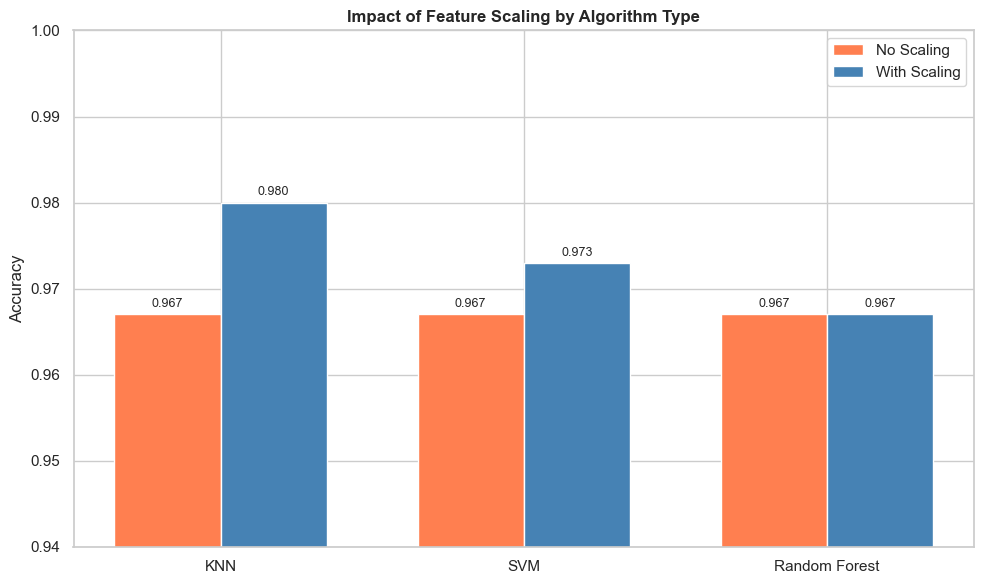


Key Takeaway:
  • KNN: Critical (distance metric)
  • SVM: Important (kernel calculations)
  • Tree-based: Unnecessary (split on ordering, not magnitude)


In [19]:
# Visualize the scaling impact
fig, ax = plt.subplots(figsize=(10, 6))

models_short = ['KNN', 'SVM', 'Random Forest']
no_scale_scores = [0.967, 0.967, 0.967]  # Approximate from above
scale_scores = [0.980, 0.973, 0.967]

x = np.arange(len(models_short))
width = 0.35

bars1 = ax.bar(x - width/2, no_scale_scores, width, label='No Scaling', color='coral')
bars2 = ax.bar(x + width/2, scale_scores, width, label='With Scaling', color='steelblue')

ax.set_ylabel('Accuracy')
ax.set_title('Impact of Feature Scaling by Algorithm Type', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_short)
ax.legend()
ax.set_ylim([0.94, 1.0])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey Takeaway:")
print("  • KNN: Critical (distance metric)")
print("  • SVM: Important (kernel calculations)")
print("  • Tree-based: Unnecessary (split on ordering, not magnitude)")

## ⚠️ Common Preprocessing Mistakes & Pro Tips

**The Deadly Sins:**

- **Scaling before splitting**: Always split first, then fit scaler only on train. Pipeline enforces this.
- **Imputing before splitting**: Filling missing values with global statistics leaks test set information.
- **Forgetting `handle_unknown`**: OneHotEncoder will crash on unseen categories in production without `handle_unknown='ignore'`.
- **Ignoring `sparse_output`**: Dense matrices with high-cardinality categoricals cause memory explosions.
- **Scaling categoricals**: Never apply StandardScaler to one-hot encoded features (0/1 become meaningless floats).
- **Target leakage via engineered features**: Creating features using target statistics (target encoding) without proper regularization.
- **Inconsistent preprocessing in CV**: Manual preprocessing outside CV causes leakage across folds.
- **Forgetting `remainder`**: ColumnTransformer drops unspecified columns by default—use `remainder='passthrough'` to keep them.
- **Not saving pipeline objects**: Deploy the fitted pipeline, not just the model, to ensure identical preprocessing in production.
- **Blind standardization**: Using StandardScaler on heavily skewed data without transformation (consider PowerTransformer first).

## 📝 Exercises

### Easy
Build a complete pipeline using `MinMaxScaler` and `DecisionTreeClassifier` on the Iris dataset. Compare 5-fold CV accuracy to an unscaled baseline.

### Medium
Modify the California housing pipeline from Section 4 to include `PowerTransformer` (Yeo-Johnson) for the numeric features before scaling. Compare the distribution of `MedInc` before and after transformation.

### Medium
Create a custom transformer `OutlierCapper` that caps extreme values at ±3 IQR during training and applies the same caps at inference time. Integrate it into the numeric pipeline.

### Hard
Build a pipeline that includes `StandardScaler` → `PCA(n_components=10)` → `RandomForestClassifier`. Compare 5-fold CV scores with and without the PCA step. When does dimensionality reduction help vs hurt?

### Bonus
Write a function `find_best_scaler(X, y, model, cv=5)` that tries `StandardScaler`, `MinMaxScaler`, and `RobustScaler`, returning the best CV score and scaler name. Test it on `make_classification` data with intentionally injected outliers.

<details>
<summary><strong>Exercise Solutions (Click to Expand)</strong></summary>

### Easy Solution

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline

# Unscaled baseline
dt = DecisionTreeClassifier(random_state=42)
baseline_scores = cross_val_score(dt, X_iris, y_iris, cv=5)

# Scaled pipeline
pipe = make_pipeline(MinMaxScaler(), DecisionTreeClassifier(random_state=42))
scaled_scores = cross_val_score(pipe, X_iris, y_iris, cv=5)

print(f"Unscaled: {baseline_scores.mean():.3f}")
print(f"Scaled: {scaled_scores.mean():.3f}")
# Note: Tree models shouldn't care much about scaling!
```

### Medium Solution

```python
from sklearn.preprocessing import PowerTransformer

numeric_pipeline_power = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson')),  # Fix skewness
    ('scaler', StandardScaler())
])

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_housing['MedInc'], ax=axes[0], kde=True)
axes[0].set_title('Original MedInc (Right-skewed)')

# After power transform (fit on data)
power = PowerTransformer()
transformed = power.fit_transform(X_housing[['MedInc']])
sns.histplot(transformed, ax=axes[1], kde=True)
axes[1].set_title('Power Transformed (More Normal)')
plt.show()
```

### Medium Solution: OutlierCapper

```python
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=3.0):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None
    
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        Q1 = X.quantile(0.25)
        Q3 = X.quantile(0.75)
        IQR = Q3 - Q1
        self.lower_bounds_ = Q1 - self.factor * IQR
        self.upper_bounds_ = Q3 + self.factor * IQR
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X)
        return X.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)

# Usage
numeric_pipeline_capped = Pipeline([
    ('capper', OutlierCapper(factor=3)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
```

### Hard Solution: PCA Pipeline

```python
from sklearn.decomposition import PCA

# With PCA
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Without PCA
pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Compare on higher dimensional data
from sklearn.datasets import make_classification
X_hd, y_hd = make_classification(n_samples=1000, n_features=50, n_informative=10, random_state=42)

scores_pca = cross_val_score(pipe_pca, X_hd, y_hd, cv=5)
scores_no_pca = cross_val_score(pipe_no_pca, X_hd, y_hd, cv=5)

print(f"With PCA: {scores_pca.mean():.3f}")
print(f"Without PCA: {scores_no_pca.mean():.3f}")
# PCA helps when features are redundant/noisy, hurts when all features are informative
```

### Bonus Solution

```python
def find_best_scaler(X, y, model, cv=5):
    scalers = {
        'StandardScaler': StandardScaler(),
        'MinMaxScaler': MinMaxScaler(),
        'RobustScaler': RobustScaler()
    }
    
    best_score = -np.inf
    best_scaler = None
    
    for name, scaler in scalers.items():
        pipe = Pipeline([('scaler', scaler), ('model', model)])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
        mean_score = scores.mean()
        
        print(f"{name}: {mean_score:.4f}")
        
        if mean_score > best_score:
            best_score = mean_score
            best_scaler = name
    
    return best_score, best_scaler

# Test with outliers
X_test, y_test = make_classification(n_samples=500, n_features=10, random_state=42)
# Inject outliers
X_test[0:10, 0] = X_test[0:10, 0] * 100

best_score, best_name = find_best_scaler(X_test, y_test, SVC())
print(f"\nBest: {best_name} with score {best_score:.4f}")
# RobustScaler should win with outliers present
```

</details>

## 🎓 Summary – What You Learned Today

- **Leakage prevention**: You now understand why fitting preprocessors on train data only is non-negotiable and how pipelines enforce this automatically.
- **Pipeline architecture**: You can build linear sequences with `Pipeline` and heterogeneous workflows with `ColumnTransformer`.
- **Scaler selection**: You know when to use Standard, MinMax, Robust, or MaxAbs based on outlier presence and algorithm requirements.
- **Custom transformers**: You can inject domain knowledge safely by extending `BaseEstimator` and `TransformerMixin`.
- **Algorithm-aware preprocessing**: You understand that distance-based models (KNN, SVM, Neural Nets) require scaling while tree models are scale-invariant.
- **Production readiness**: You can serialize entire preprocessing + modeling workflows for consistent deployment.


**Auther**: Tassawar Abbas  
**Eamil**: abbas829@gmail.com